In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from AnchorGen import Anchor, Vector
import AnchorGen as Anc

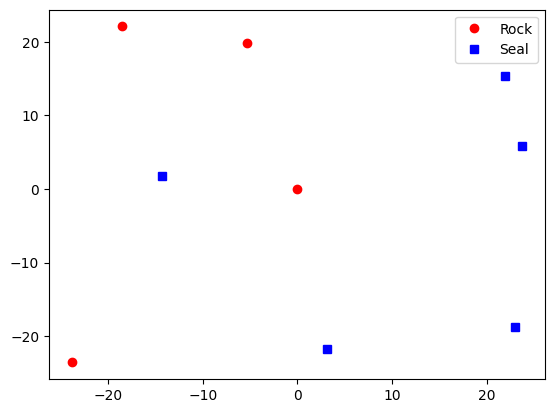

In [2]:
anchors = Anc.generate_anchors_grid()
plt.plot([anchor.position[0] for anchor in anchors if anchor.type == 'rock'], [anchor.position[1] for anchor in anchors if anchor.type == 'rock'], 'ro', label='Rock')
plt.plot([anchor.position[0] for anchor in anchors if anchor.type == 'seal'], [anchor.position[1] for anchor in anchors if anchor.type == 'seal'], 'bs', label='Seal')
plt.legend()
plt.show()

In [3]:
import numpy as np

def tangent_generation(anchor1, anchor2):
    r1 = anchor1.radius()
    r2 = anchor2.radius()
    c1 = anchor1.position
    c2 = anchor2.position
    
    # Vector between centers
    d = c2 - c1
    dist = np.linalg.norm(d)
    
    # Unit vector between centers
    u = d / dist
    
    # Perpendicular unit vector
    v = np.array([-u[1], u[0]])
    
    tangents = []
    
    # Case 1: Outer tangents (both circles on same side of tangent line)
    if abs(r1 - r2) < dist:
        # Angle for outer tangents
        angle_outer = np.arccos((r1 - r2) / dist) if r1 > r2 else np.arccos((r2 - r1) / dist)
        
        # Direction vectors for outer tangents
        dir1 = u * np.cos(angle_outer) + v * np.sin(angle_outer)
        dir2 = u * np.cos(angle_outer) - v * np.sin(angle_outer)
        
        # Tangent points on circle 1
        p1_1 = c1 + r1 * dir1
        p1_2 = c1 + r1 * dir2
        
        # Tangent points on circle 2
        p2_1 = c2 + r2 * dir1
        p2_2 = c2 + r2 * dir2
        
        tangents.append((p1_1, p2_1))
        tangents.append((p1_2, p2_2))
    
    # Case 2: Inner tangents (circles on opposite sides of tangent line)
    if r1 + r2 < dist:
        # Angle for inner tangents
        angle_inner = np.arccos((r1 + r2) / dist)
        
        # Direction vectors for inner tangents
        dir3 = u * np.cos(angle_inner) + v * np.sin(angle_inner)
        dir4 = u * np.cos(angle_inner) - v * np.sin(angle_inner)
        
        # Tangent points on circle 1
        p1_3 = c1 + r1 * dir3
        p1_4 = c1 + r1 * dir4
        
        # Tangent points on circle 2 (note the negative sign for opposite side)
        p2_3 = c2 - r2 * dir3
        p2_4 = c2 - r2 * dir4
        
        tangents.append((p1_3, p2_3))
        tangents.append((p1_4, p2_4))
    
    # If circles are externally tangent (r1 + r2 == dist), return 3 tangents
    # If one circle is inside another without touching, return 0 tangents
    # The conditions above handle these cases automatically
    
    return tangents

In [4]:
def plot_vector(optimal_vector,anchors):
    plt.plot([optimal_vector.a[0]-100*optimal_vector.v[0], optimal_vector.a[0]+100*optimal_vector.v[0]], [optimal_vector.a[1]-100*optimal_vector.v[1], optimal_vector.a[1]+100*optimal_vector.v[1]])
    plt.axis([-30, 30, -30, 30])
    plt.plot([anchor.position[0] for anchor in anchors if anchor.type == 'rock'], [anchor.position[1] for anchor in anchors if anchor.type == 'rock'], 'ro', label='Rock')
    plt.plot([anchor.position[0] for anchor in anchors if anchor.type == 'seal'], [anchor.position[1] for anchor in anchors if anchor.type == 'seal'], 'bs', label='Seal')
    plt.legend()
    plt.show()

In [5]:
def solve(anchors):
    steps = 0
    while len(anchors) >= 3:
        vector_list = []
        comb = combinations(anchors, 2) # n choose 2 = n(n-1)/2 combinations of anchors
        for anchor1, anchor2 in comb:
            tangents = tangent_generation(anchor1, anchor2)
            for tangent in tangents:
                a = tangent[0]
                v = tangent[1] - tangent[0]
                vector_list.append(Vector(a,v))
        score_list = []
        for vector in vector_list:
            score = 0.0
            for anchor in anchors:
                if vector.distance_to_point(anchor.position) <= anchor.radius() + 0.01: # 0.01 tolerance to account for floating point errors
                    score += anchor.score
            score_list.append((score, vector))
        score_list.sort(key=lambda x: x[0], reverse=True)
        optimal_vector = score_list[0][1]
        # plot_vector(optimal_vector, anchors)
        to_remove = []
        for anchor in anchors:
            if optimal_vector.distance_to_point(anchor.position) <= anchor.radius() + 0.01:
                anchor.destroy()
                if anchor.type == 'destroyed':
                    to_remove.append(anchor)
        for anchor in to_remove:
            anchors.remove(anchor)
        steps += 1
    if len(anchors) == 2:
        anchor1, anchor2 = anchors
        optimal_vector = Vector(anchor1.position, anchor2.position - anchor1.position)
        # plot_vector(optimal_vector, anchors)
        steps += 1
    if len(anchors) == 1:
        anchor = anchors[0]
        optimal_vector = Vector(anchor.position, np.array([1,0])) # arbitrary vector through the last anchor
        # plot_vector(optimal_vector, anchors)
        steps += 1
    return steps

In [6]:
step_list = []
for i in range(1000):
    anchors = Anc.generate_anchors_grid()
    step_list.append(solve(anchors))
step_list = np.array(step_list)
print(np.count_nonzero(step_list == 4), np.count_nonzero(step_list == 5))

80 919


In [7]:
print(np.count_nonzero(step_list == 6))

1
